In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as C
import sys
sys.path.append("..")
from AIEM import AIEM

In [2]:
freq = 13e9
epsilon_r = 15-4j
# subsurface
delta = 0.15e-2
corr_len = 1.5e-2

c = C.speed_of_light
Lambda = c / freq
k = np.pi * 2 / Lambda

kdel = k * delta
kcor = k * corr_len
# kdel = 0.2
# kcor = 1.0
aiem = AIEM(epsilon_r, kdel, kcor, corr_fun='exp', x=1.5, shadow_flag=False)

In [3]:
M = aiem.Mue_noncoh_R((30, 180, 30, 0))

(-50.0, 20.0)

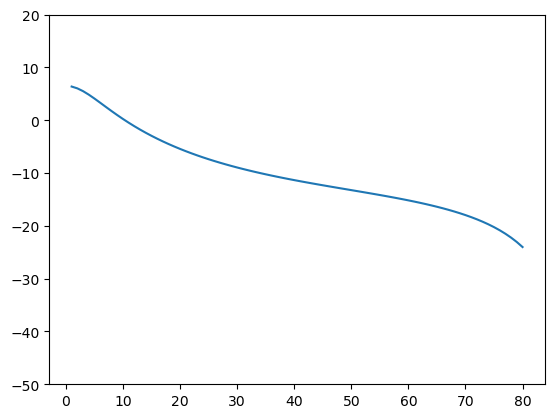

In [4]:
# Backscattering test
N = 80
theta_is = np.linspace(1, 80, N)
sigma_VV_dB = np.zeros(N)

for i in range(N):
    theta_i = theta_is[i]
    theta_s = theta_i
    M = aiem.Mue_noncoh_R((theta_s, 180, theta_i, 0))
    sigma_VV_dB[i] = 10*np.log10(4*np.pi*M[0, 0])
    # sigma_VV_dB[i] = M[0,0]

plt.plot(theta_is, sigma_VV_dB)
plt.ylim(-50, 20)

In [9]:
import matlab.engine

In [10]:
matlab_eng = matlab.engine.start_matlab()
is_matlab_started = True
matlab_eng.cd(r'E:/exps/lunar_scattering/lunar_regolith_scattering/mores/matlab', nargout=0)

In [14]:

f = 13e9
theta_is = np.linspace(1, 80, 80)
c = 3e8
Lambda = c / f
k = 2 * np.pi / Lambda
delta = 0.15e-2
corr_len = 1.5e-2
epsilon_1 = 1
epsilon_2 = 15.0-4j

phi_i = 0
phi_s = 180
N = len(theta_is)
sigma_vv_dB = np.zeros(N)
for i in range(N):
    theta_i = theta_is[i]
    theta_s = theta_i
    angle_s = matlab.double([theta_s, phi_s])
    angle_i = matlab.double([theta_i, phi_i])
    sp = matlab.double([delta, corr_len])
    SpR = 'exp'
    R = matlab_eng.Fun_R_rough_AIEMs_noRvplusRh(f, angle_s, angle_i, 
            epsilon_1, epsilon_2, sp, SpR, 1, False, nargout=1)
    sigma_vv_dB[i] = 10*np.loog10(4*np.pi*R[0,0])

plt.plot(theta_is, sigma_vv_dB)

MatlabExecutionError: 
  File E:\exps\lunar_scattering\lunar_regolith_scattering\mores\matlab\Fun_R_rough_AIEMs_noRvplusRh.m, line 105, in Fun_R_rough_AIEMs_noRvplusRh
不支持复整数算术运算。
